In [1]:
import os
import numpy as np
import pandas as pd
import shutil
from read_roi import read_roi_file
import tifffile
import matplotlib.pyplot as plt
import create_mask_for_region
from datetime import datetime
from contour_visualization import *

#import shap
# read heatmap plots
#import Heatmap_plots as hmp
import seaborn as sns
import pickle
import tifffile as tiff

def flatten_extend(matrix):
    flat_list = []
    for row in matrix:
        flat_list.extend(row)
    return flat_list

In [2]:
import numpy as np

def set_transparency(rgba_img, mask):
    """
    Applies a transparency mask to an existing RGBA image.

    Parameters:
    - rgba_img: np.ndarray of shape (H, W, 4), dtype uint8
        The input RGBA image.
    - mask: np.ndarray of shape (H, W), dtype bool
        Boolean mask where True means the pixel should be transparent.

    Returns:
    - np.ndarray of shape (H, W, 4), modified RGBA image.
    """
    if rgba_img.shape[-1] != 4:
        raise ValueError("Input image must be RGBA (shape must be H x W x 4).")
    if rgba_img.shape[:2] != mask.shape:
        raise ValueError("Mask shape must match image height and width.")

    # Copy to avoid modifying the original
    result = rgba_img.copy()
    result[mask, 3] = 0  # Set alpha to 0 (transparent) where mask is True
    return result


In [3]:
# set figure key
figure_key = 'Figure3'

In [4]:
# set paths
result_paths = "data"
rootpath = os.path.dirname(os.getcwd())
datapath = os.path.join(rootpath,"data")
metapath = os.path.join(rootpath,"meta")
analysis_resultpath = os.path.join(datapath,"result")
analysis_spatial = os.path.join(datapath,"spatial")
analysis_atlaspath = os.path.join(datapath,"atlas")

analysis_root_figurepath = os.path.join(rootpath,"figure")
analysis_figurepath = os.path.join(analysis_root_figurepath,figure_key)
for path in [analysis_resultpath,analysis_root_figurepath,analysis_figurepath]:
    if not os.path.exists(path):
        os.mkdir(path)

# load meta info of the files
metadf = pd.read_csv(os.path.join(metapath,"OP_meta.csv"),index_col= False)
# drop of A7 due to missing data
metadf = metadf[metadf.ID != 'A7'].reset_index(drop = True)
# load brain atlas to register
atlas_df = pd.read_csv(os.path.join(analysis_atlaspath,"atlas_info_KimRef_FPbasedLabel_v4.0_brain_with_size_with_curated_with_cleaned_acronyms.csv"),index_col = False)
metacolumns = ['id','acronym','parent_acronym','parent_id','structure_order']
contour_img = tifffile.imread(os.path.join(analysis_atlaspath,"Kim_ref_adult_FP-label_v2.9_contour_map.tif"))
# retrieve list of files
fnames =  [f for f in metadf.fname.values if 'DONE' in f]
print(fnames)

['20240227_17_25_07_OP_A1E_Destripe_DONE', '20240227_17_06_12_OP_A2F_Destripe_DONE', '20240227_18_01_17_OP_A3G_Destripe_DONE', '20240227_18_21_05_OP_A4H_Destripe_DONE', '20240403_13_21_45_OP_A5Q_Destripe_DONE', '20240403_13_40_56_OP_A6R_Destripe_DONE', '20240403_16_25_18_OP_A8T_Destripe_DONE', '20240227_14_10_33_OP_C1A_Destripe_DONE', '20240227_14_30_11_OP_C2B_Destripe_DONE', '20240227_15_33_16_OP_C3C_Destripe_DONE', '20240227_15_52_19_OP_C4D_Destripe_DONE', '20240403_17_39_38_OP_C5U_Destripe_DONE', '20240403_17_19_10_OP_C6U_Destripe_DONE', '20240403_18_37_53_OP_C7W_Destripe_DONE', '20240403_18_58_24_OP_C8X_Destripe_DONE', '20240227_23_20_32_OP_S1I_Destripe_DONE', '20240227_23_00_56_OP_S2J_Destripe_DONE', '20240228_10_52_10_OP_S3L_Destripe_DONE', '20240228_11_13_31_OP_S4K_Destripe_DONE', '20240403_10_59_33_OP_S5M_Destripe_DONE', '20240403_11_19_31_OP_S6N_Destripe_DONE', '20240403_12_02_34_OP_S7O_Destripe_DONE', '20240403_12_21_49_OP_S8P_Destripe_DONE', '20240525_14_22_32_OP_MoW1A_Destr

In [5]:
#Conditions = metadf.Condition.unique()
# Use only morphine related groups
# Withdrawal_Morphine: EarlyWD
# Chronic_Morphine_21: Re-exposure
# Withdrawal_Morphine: LateWD
Conditions = ['Saline','Acute_Morphine','Chronic_Morphine','Withdrawal_Morphine','Chronic_Morphine_21','Withdrawal_Morphine_21',]
print(Conditions)

# subset the meta dataframe
metadf = metadf[metadf.Condition.isin(Conditions)]

['Saline', 'Acute_Morphine', 'Chronic_Morphine', 'Withdrawal_Morphine', 'Chronic_Morphine_21', 'Withdrawal_Morphine_21']


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from adjustText import adjust_text

# Set matplotlib parameters for white text on transparent background
plt.rcParams.update({
    'figure.facecolor': 'none',  # Transparent figure background
    'axes.facecolor': 'none',    # Transparent axes background
    'axes.edgecolor': 'black',   # White axes edge color
    'axes.labelcolor': 'black',  # White axis labels
    'xtick.color': 'black',      # White tick labels
    'ytick.color': 'black',      # White tick labels
    'legend.facecolor': 'none',  # Transparent legend background
    'legend.edgecolor': 'none',  # Transparent legend edgecolor
    'text.color': 'black',       # White text color
    'font.family':'Arial',
    'pdf.fonttype':42,
    'ps.fonttype':42,
   
})
#important for text to be detected when importing saved figures into illustrator


In [7]:
with open(os.path.join(analysis_atlaspath,f'curated_acronym.pickle'), 'rb') as handle:
    curated_acronyms = pickle.load(handle)

with open(os.path.join(analysis_atlaspath,f'ancestor_curated_acronym.pickle'), 'rb') as handle:
    ancestor_curated_acronyms = pickle.load(handle,)

In [8]:
default_depth = 4
# set heatmap variables
vmin= -5
vmax = 10

#Conditions = metadf.Condition.unique()
# Use only morphine related groups
Conditions = ['Saline','Acute_Morphine','Chronic_Morphine','Withdrawal_Morphine','Chronic_Morphine_21','Withdrawal_Morphine_21',]
print(Conditions)
#Condition_figure_name = ['Saline','Acute','Chronic 1 day','W.D. 1 day','Chronic 21 days','W.D. 21 days'] # changed this to betterones
Condition_figure_name = ['Saline','Acute','Chronic','Early WD','Re-exposure','Late WD'] 
Condition_color = ['gray','lime','orange','cyan','blue','purple']
# subset the meta dataframe
metadf = metadf[metadf.Condition.isin(Conditions)]


['Saline', 'Acute_Morphine', 'Chronic_Morphine', 'Withdrawal_Morphine', 'Chronic_Morphine_21', 'Withdrawal_Morphine_21']


In [9]:
# load and subset dataframes
pivot_heatmap_df = pd.read_csv(os.path.join(analysis_resultpath,'OP_cFos_heatmap.csv'),index_col = 0)
pivot_heatmap_df = pivot_heatmap_df[metadf[metadf.Condition.isin(Conditions)]['ID'].values]
merge_df  = pd.read_csv(os.path.join(analysis_resultpath,'OP_cFos_full_result.csv'),index_col = 0)
merge_df = merge_df[merge_df.Condition.isin(Conditions)]
merge_df = merge_df[merge_df.fname.isin(fnames)]

In [10]:
assert (merge_df.fname.unique() == fnames).all() # check if all the fnames are present
assert (pivot_heatmap_df.columns == metadf.ID.unique()).all() # check if all the IDs are present

In [11]:
print("Number of animals per groups")
print(metadf.groupby('Condition').size())

Number of animals per groups
Condition
Acute_Morphine            7
Chronic_Morphine          8
Chronic_Morphine_21       6
Saline                    8
Withdrawal_Morphine       8
Withdrawal_Morphine_21    6
dtype: int64


remove HB and CBL from the list of ancestores

In [13]:
# Update the ancestor curated acronyms so it matches the tree devisions
unique_ancestor_curated_acronyms = ['Isocortex','OLF','HPF','CTXsp','STR','PAL','TH','HY','MB',]
#unique_ancestor_curated_acronyms = ['Isocortex','OLF','HPF','CTXsp','STR','PAL','TH','HY','MB','HB','CBL']

# get a list of idx for the ancestors
ancestor_names = [atlas_df.loc[atlas_df.acronym == f,'name'].values[0] for f in unique_ancestor_curated_acronyms]
ancestor_idxs = [atlas_df.loc[atlas_df.acronym == f,'id'].values[0] for f in unique_ancestor_curated_acronyms]


remove CBL and MB subtree from the atlas file and the merge_df

In [14]:
# remove CBL and MB subtree from the data. These regions had bad registration quality and low interest
remove_ancestor_ids = atlas_df[(atlas_df.acronym == 'HB') | (atlas_df.acronym == 'CBL')]['id'].values
remove_df = pd.concat([create_mask_for_region.get_subregions(atlas_df,idx,return_original = True) for idx in remove_ancestor_ids],axis = 0)
sub_atlas_df = atlas_df.set_index(['id']).drop(remove_df['id'].values)
merge_df = merge_df[merge_df.acronym.isin(sub_atlas_df.acronym.unique())]

set up the metacolumns to be compatible for GLM

In [15]:
# load meta info of the files
metadf['age'] = [(datetime.strptime( pday, '%m/%d/%Y') - datetime.strptime( dob, '%m/%d/%Y')).days for pday,dob in metadf.loc[:,['Date_Perfusion','DOB']].values]
atlasmeta = merge_df.reset_index().loc[merge_df.reset_index().ID =='A1',['id','parent_id','acronym','name','parent_acronym']]


In [16]:
# change categorical values to dummy chategories dtypes
sex_category = pd.CategoricalDtype(categories=['F', 'M'], ordered=False)
condition_category = pd.CategoricalDtype(categories=Conditions, ordered=True)
batch_category = pd.CategoricalDtype(categories=[1,2,3,4], ordered=False)

merge_df['Sex']             = merge_df['Sex'].astype(sex_category)
merge_df['Condition']       = merge_df['Condition'].astype(condition_category)

merge_df['Staining_Batch']  = merge_df['Staining_Batch'].astype(batch_category)

# create dummy cats
condition_dummies           = pd.get_dummies(merge_df['Condition'])
sex_dummies                 = pd.get_dummies(merge_df['Sex']).loc[:,['F']].rename(columns = {'F':'Sex_d'}) # female 1
batch_dummies = pd.get_dummies(merge_df['Staining_Batch'])
batch_dummies.columns = [f'Batch_{c}_d' for c in range(4)]

merge_df                    = pd.concat([merge_df,condition_dummies,sex_dummies,batch_dummies],axis =1)

In [40]:
# add flags for conditions
#merge_df = pd.merge(merge_df,metadf[['ID','Acute_flag','Chronic_flag','Spontaneous_flag']],left_on = 'ID',right_on = 'ID')

In [17]:
# calculate effect size raw
raw_effect_size_df = merge_df[['acronym','Condition','density']].groupby(['acronym','Condition',]).mean().reset_index()\
.pivot(columns = 'Condition',index = 'acronym',values = 'density')

C:\Users\stuberadmin\AppData\Local\Temp;\ipykernel_42484\3994839575.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw_effect_size_df = merge_df[['acronym','Condition','density']].groupby(['acronym','Condition',]).mean().reset_index()\


In [18]:
#atlas_df.loc[atlas_df.acronym.isin(curated_acronyms),['acronym','name']].to_csv(os.path.join(metapath,'clean_curated_acronyms.csv'),index = False)

Prepare heatmaps into a dictionary format

In [19]:
# read an annotated atlas file
atlas_img = tifffile.imread(os.path.join(analysis_atlaspath,"Kim_ref_adult_FP-label_v4.0.tif"))

# Figure 3

In [20]:
# read the results from the whole treeFDR f
TreeFDRS_df = pd.read_csv(os.path.join(analysis_resultpath,\
    f'TreeFDRS_pvalue_Figure2_C_glm_stat_df.csv'),index_col = False)

# get the rejected acronyms
rejected_acronyms = TreeFDRS_df[(TreeFDRS_df.acronym.isin(curated_acronyms)) & (TreeFDRS_df.rejected == True)].acronym.values 
print(len(rejected_acronyms)," rejected acronyms")
print(rejected_acronyms)


89  rejected acronyms
['FrA' 'M1' 'M2' 'S1' 'S2' 'A24a (IL)' 'DI' 'GI' 'AuD' 'Au1' 'AuV' 'V2L'
 'V2M' 'V1' 'A24 (Cg)' 'A32 (PrL)' 'O' 'AI' 'A29-30 (RS)' 'PtA' 'TeA '
 'AO' 'TT' 'A25 (DP)' 'RAPir' 'CA3' 'DIEnt' 'VIEnt' 'MEnt' 'Post' 'PsS'
 'DS' 'VeS' 'STr' 'Cl' 'La' 'CPre' 'CPi' 'CPc' 'AcbC' 'AcbSh' 'IPAC' 'Tu'
 'Ce' 'Sc' 'PIL' 'PP' 'MG' 'Po' 'PLi' 'SG' 'AM' 'IAM' 'IAD' 'IMD' 'PoMn'
 'MD' 'Sub' 'PVT' 'PT' 'Rh' 'CM' 'PC' 'IGL' 'PrG' 'SubG' 'PS' 'MBO' 'RCh'
 'ZI' 'Com' 'PaR' 'VTA' 'PlPAG' 'Lth' 'Dk' 'Su3' 'MA3' 'PrEW' '4Sh' 'Pa4'
 'VTg' 'SNC' 'SPTg' 'IF' 'IP' 'RLi ' 'CLi' 'DR']


## Figure 3B

In [21]:
pannel_key = 'B'

In [22]:
# No cluster
# sort by pvalues
condition1 = 'Saline'
condition2 = 'Acute_Morphine'

In [23]:
# subset to the submerge_df
sub_merge_df = merge_df[merge_df.Condition.isin([condition1,condition2])]

In [24]:
# add pvalues to a dataframe
effect_size_df = sub_merge_df[['acronym','Condition','normalized_density']].groupby(['acronym','Condition']).mean().reset_index().pivot(index = 'acronym',columns = 'Condition',values = 'normalized_density')
from scipy.stats import ttest_ind
# for each unique acronym in sub_merge_df, conduct a ttest_ind using the Condition variable

for acronym in sub_merge_df.acronym.unique():
    #print(acronym)
    
    saline_array = sub_merge_df[(sub_merge_df.Condition == 'Saline') & (sub_merge_df.acronym == acronym)]['normalized_density'].values.astype('float')
    condition_array = sub_merge_df[(sub_merge_df.Condition == condition2) & (sub_merge_df.acronym == acronym)]['normalized_density'].values.astype('float')
    #
    s_,p_ = ttest_ind(saline_array, condition_array)
    effect_size_df.loc[acronym,f'Saline_vs_{condition2}_pvalue'] = p_
    effect_size_df.loc[acronym,f'Saline_vs_{condition2}_delta'] = np.mean(condition_array) - np.mean(saline_array)
    effect_size_df.loc[acronym,f'Saline_vs_{condition2}_signed_strength'] = -np.log10(p_) * np.sign(np.mean(condition_array) - np.mean(saline_array))



C:\Users\stuberadmin\AppData\Local\Temp;\ipykernel_42484\1588428337.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  effect_size_df = sub_merge_df[['acronym','Condition','normalized_density']].groupby(['acronym','Condition']).mean().reset_index().pivot(index = 'acronym',columns = 'Condition',values = 'normalized_density')


In [25]:
# run post hoc analysis
from statsmodels.stats import multitest
stats,qvalues,__,__ = multitest.multipletests(effect_size_df.loc[rejected_acronyms,f'Saline_vs_{condition2}_pvalue'],method ='fdr_bh',alpha = 0.05)
effect_size_df.loc[rejected_acronyms,f'Saline_vs_{condition2}_posthoc_rejected'] = stats
effect_size_df.loc[rejected_acronyms,f'Saline_vs_{condition2}_posthoc_qadj'] = qvalues

In [26]:
# clean up the dataframes
from statsmodels.stats import multitest

# flatten the list
sorted_effect_size_df = effect_size_df.sort_values(by = [f'Saline_vs_{condition2}_pvalue']).loc[rejected_acronyms,[\
    f'Saline_vs_{condition2}_pvalue',f'Saline_vs_{condition2}_delta',f'Saline_vs_{condition2}_posthoc_rejected']]
    
stats = sorted_effect_size_df[f'Saline_vs_{condition2}_posthoc_rejected'].values

# Use pd.isna for nan, and direct comparison for True/False
true_mask = stats == True
false_mask = stats == False
nan_mask = pd.isna(stats)

true_acronyms = sorted_effect_size_df[true_mask].sort_values(by=f'Saline_vs_{condition2}_delta', ascending=False).index
false_acronyms = sorted_effect_size_df[false_mask].sort_values(by=f'Saline_vs_{condition2}_delta', ascending=False).index
nan_acronyms = sorted_effect_size_df[nan_mask].sort_values(by=f'Saline_vs_{condition2}_delta', ascending=False).index

sorted_acronyms_list = list(true_acronyms) + list(false_acronyms) + list(nan_acronyms)
sorted_cleaned_acronyms_list = [atlas_df[atlas_df.acronym == f].cleaned_acronym.values[0] for f in sorted_acronyms_list]
stats = sorted_effect_size_df.loc[sorted_acronyms_list,f'Saline_vs_{condition2}_posthoc_rejected'].values

In [27]:
stat_strings = []
for f in stats:
    if np.isnan(f):
        stat_strings.append('n.t.')
    elif f == False:
        stat_strings.append('n.d.')
    elif f:
        #print(f)
        stat_strings.append('*')

C:\Users\stuberadmin\AppData\Local\Temp;\ipykernel_42484\1411773395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_merge_df.Condition = sub_merge_df.Condition.astype('str')
C:\Users\stuberadmin\AppData\Local\Temp;\ipykernel_42484\1411773395.py:5: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.stripplot(data = sub_merge_df[(sub_merge_df.acronym.isin(rejected_acronyms))&(sub_merge_df.Condition.isin([condition2]))],
C:\Users\stuberadmin\AppData\Local\Temp;\ipykernel_42484\1411773395.py:10: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.pointplot(sub_

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

IAD_Acute_Morphine vs. IAD_Saline: t-test independent samples with Benjamini-Hochberg correction, P_val:3.219e-04 t=4.842e+00
PT_Acute_Morphine vs. PT_Saline: t-test independent samples with Benjamini-Hochberg correction, P_val:1.161e-04 t=5.425e+00
CPre_Acute_Morphine vs. CPre_Saline: t-test independent samples with Benjamini-Hochberg correction, P_val:7.700e-04 t=4.362e+00
DR_Acute_Morphine vs. DR_Saline: t-test independent samples with Benjamini-Hochberg correction, P_val:6.560e-05 t=5.764e+00
4Sh_Acute_Morphine vs. 4Sh_Saline: t-test independent samples with Benjamini-Hochberg correction, P_val:3.875e-03 t=3.505e+00
CLi_Acute_Morphine vs. CLi_Saline: t-test independent samples with Benjamini-Hochberg correction, P_val:2.326e-06 t=7.971e+00
Ce_Acute_Morphine vs. Ce_Saline: t-test independent sa

(<Axes: ylabel='c-Fos+ cell density\n(normalized to saline)'>,
  <statannotations.Annotation.Annotation at 0x251bfd9ce00>])

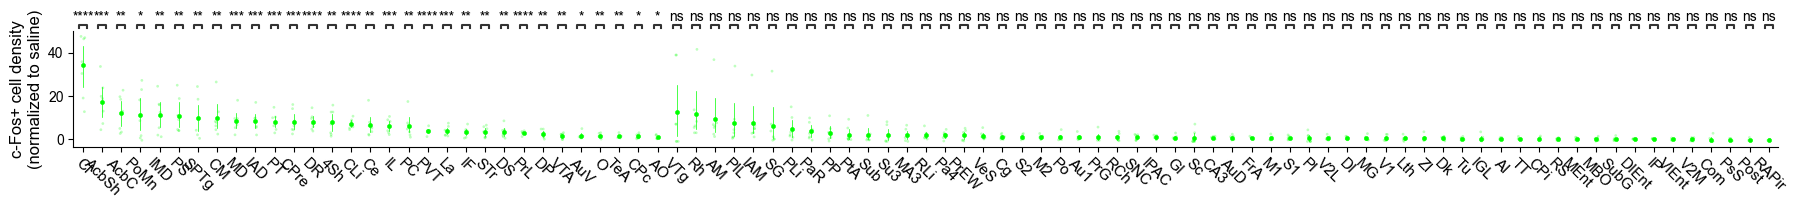

In [28]:

fig,axs = plt.subplots(1,1,figsize = (22,1.5))

sub_merge_df.Condition = sub_merge_df.Condition.astype('str')
#sub_merge_df = sub_merge_df.reset_index()
sns.stripplot(data = sub_merge_df[(sub_merge_df.acronym.isin(rejected_acronyms))&(sub_merge_df.Condition.isin([condition2]))],
            hue = 'Condition',y = 'normalized_density',x = 'acronym',dodge = False,
            order = sorted_acronyms_list,\
            hue_order = [condition1,condition2],ax = axs,\
            palette = np.array(Condition_color)[[0,1]],alpha = 0.25,size = 2)
sns.pointplot(sub_merge_df[(sub_merge_df.acronym.isin(rejected_acronyms))&(sub_merge_df.Condition.isin([condition2]))],
            hue = 'Condition',y = 'normalized_density',x = 'acronym',order = sorted_acronyms_list,
        hue_order = [condition1,condition2],ax = axs,palette = np.array(Condition_color)[[0,1]],
markers="o", markersize=3, linestyle="none",linewidth = 0.5)  
sns.despine()
axs.set_xticklabels(sorted_cleaned_acronyms_list,fontsize = 11,rotation = -45)
# remove legend
axs.get_legend().remove()
axs.set_xlabel('')
axs.set_ylabel('c-Fos+ cell density\n(normalized to saline)',fontsize = 12)
# add a horizontal line to separate the clusters
#borders = [0] + list(np.cumsum(nregions_list))
#[axs.axvline(border - 0.5,color = 'gray',lw = 2,ls = ':') for border in borders[1:-1]]


#for aidx, an in enumerate(stat_strings):
#    axs.text(aidx , sub_merge_df[(sub_merge_df.acronym.isin(rejected_acronyms))&(sub_merge_df.Condition.isin([condition2]))].normalized_density.values.max()
#             , an, ha='center', va='bottom')
from statannotations.Annotator import Annotator
pairs = [((c,condition1),(c,condition2)) for c in sorted_acronyms_list]

annotator = Annotator(axs, pairs, data = sub_merge_df[(sub_merge_df.Condition.isin([condition1,condition2]))],
            hue = 'Condition',y = 'normalized_density',x = 'acronym',
            order = sorted_acronyms_list,)
annotator.configure(test='t-test_ind', text_format='star', loc='outside',)
annotator.configure(comparisons_correction="BH", correction_format="replace")
annotator.set_custom_annotations(stat_strings)
annotator.apply_and_annotate()


#fig.savefig(os.path.join(analysis_figurepath,f'{figure_key}{pannel_key}.png'),bbox_inches = 'tight',dpi = 216)
#fig.savefig(os.path.join(analysis_figurepath,f'{figure_key}{pannel_key}.pdf'),bbox_inches = 'tight')



In [ ]:
# write the effect size dataframe to a csv file
#effect_size_df.to_csv(os.path.join(analysis_resultpath,f'{figure_key}{pannel_key}_effect_size_df.csv'),index = True)
print(effect_size_df)